In [ ]:
# dataset link https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset?resource=download

### Heart Disease Prediction using Machine Learning

### First, I'm importing the libraries I will need.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. Load the Data ---
# Loading the heart.csv file into a pandas DataFrame.

In [ ]:
print("--- Loading data ---")
df = pd.read_csv('heart.csv')

--- Loading data ---


# --- 2. Explore the Data ---

In [ ]:


# --- 2. Explore the Data ---
print("\n--- Basic Data Info ---")
print("First 5 rows of the data:")
print(df.head())

print("\nData summary and types:")
df.info()

print("\nStatistical details:")
print(df.describe())


--- Basic Data Info ---
First 5 rows of the data:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Data summary and types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3 

# --- 3. Clean the Data ---

In [ ]:
# The .info() command showed no missing values, which is great.
# But I should check for duplicates.
print("\n--- Cleaning Data ---")
duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate rows.")

# Removing the duplicates.
df.drop_duplicates(inplace=True)
print(f"Dataset shape after removing duplicates: {df.shape}")


--- Cleaning Data ---
Found 723 duplicate rows.
Dataset shape after removing duplicates: (302, 14)


# --- 4. Exploratory Data Analysis (EDA) ---


--- Performing EDA ---


/tmp/ipykernel_5998/1268623922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


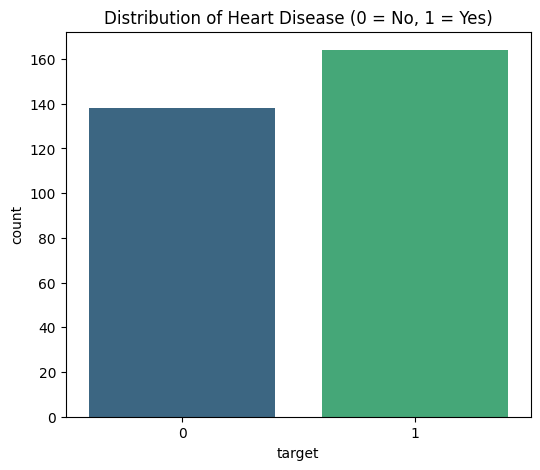

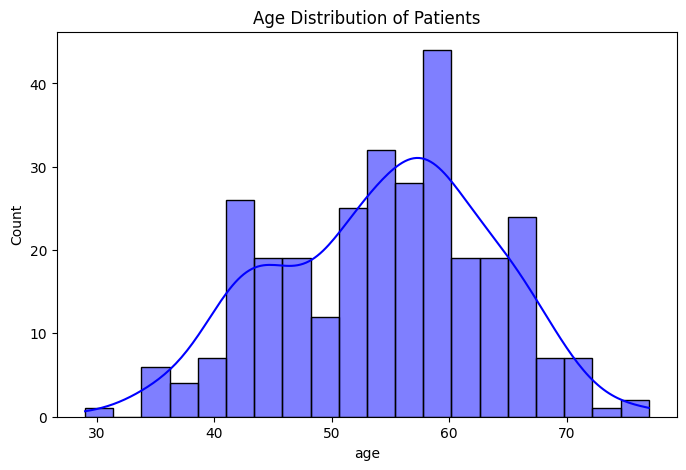

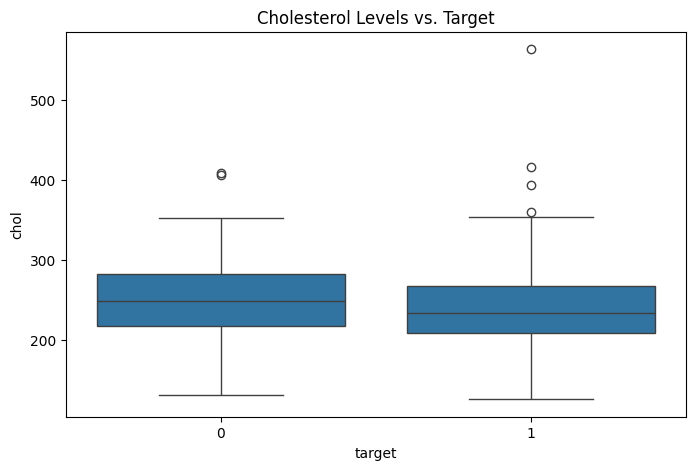

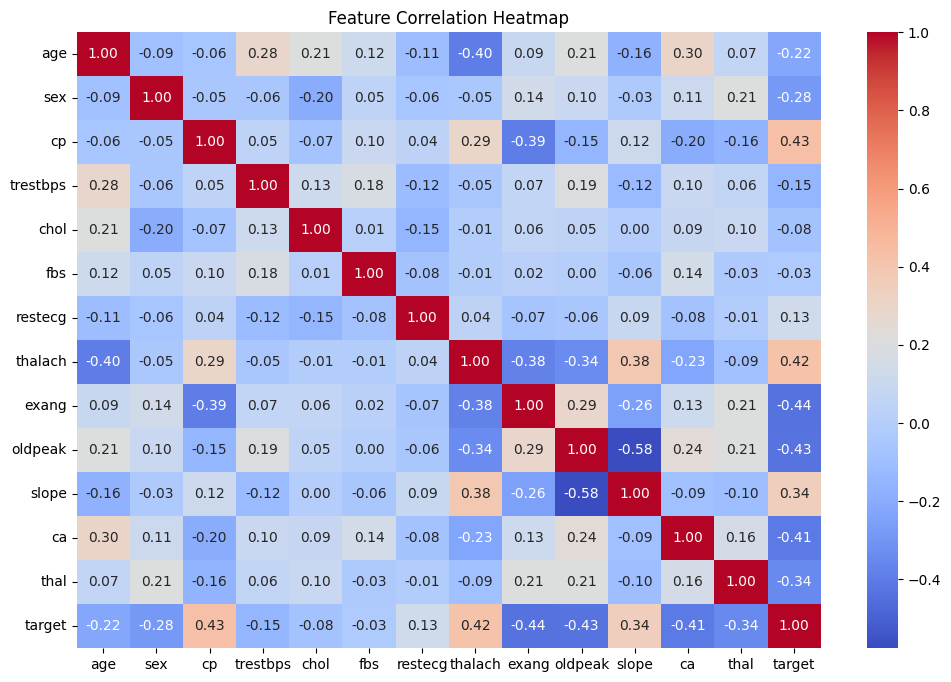

In [ ]:
# I'll make some plots to understand the data better.
# I will save them in a folder called 'plots'.
print("\n--- Performing EDA ---")

# Plot 1: Target Variable Distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.show() # This displays the plot in the notebook

# Plot 2: Age Distribution (Requirement: Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='blue')
plt.title('Age Distribution of Patients')
plt.show()



# Plot 3: Cholesterol Levels (Requirement: Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='chol', data=df)
plt.title('Cholesterol Levels vs. Target')
plt.show()

# Plot 4: Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# --- 5. Prepare Data for Machine Learning ---

In [ ]:
print("\n--- Preparing data for modeling ---")

# 'X' will have all the features, 'y' will have the target variable.
X = df.drop('target', axis=1)
y = df['target']

# Splitting the data: 80% for training, 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Scaling the numerical features. This is important.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


--- Preparing data for modeling ---
Training data shape: (241, 13)
Testing data shape: (61, 13)


# --- 6. Train and Evaluate Models ---

In [ ]:
# Model 1: Logistic Regression
print("\n--- Logistic Regression ---")
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2%}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Model 2: Decision Tree
print("\n--- Decision Tree ---")
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.2%}")
print("Classification Report:")
print(classification_report(y_test, y_pred_tree))

# Model 3: Random Forest
print("\n--- Random Forest ---")
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X_train, y_train)
y_pred_forest = forest_clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_forest):.2%}")
print("Classification Report:")
print(classification_report(y_test, y_pred_forest))


--- Logistic Regression ---
Accuracy: 77.05%
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61


--- Decision Tree ---
Accuracy: 73.77%
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.74      0.69      0.71        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61


--- Random Forest ---
Accuracy: 83.61%
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.8

# --- 7. Final Model Evaluation ---


--- Best Model: Random Forest ---


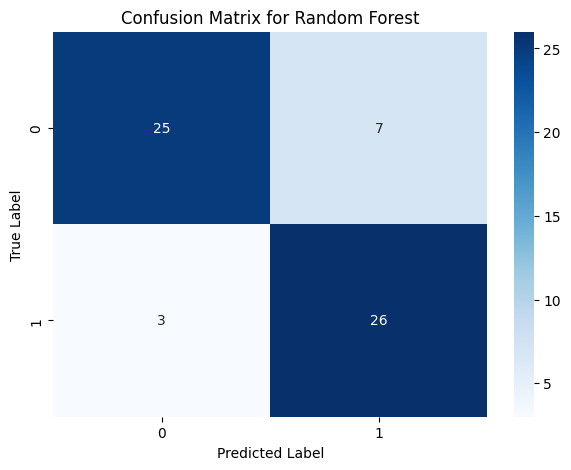

In [ ]:
# The Random Forest model seems to have the best accuracy.
# I'll create a confusion matrix for it to see where it made mistakes.

print("\n--- Best Model: Random Forest ---")
cm = confusion_matrix(y_test, y_pred_forest)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show() # Changed from savefig to show